# 04 — Modelo final y evaluación en test set

Este notebook define el **modelo final** del proyecto a partir de todo lo aprendido en los Sprints 1–3c y lo evalúa **una única vez** sobre `test_speaker_independent`.

## Protocolo de apertura de test

Hasta este notebook, `test_speaker_independent` nunca fue cargado con fines de modelado (ver auditoría de leakage en `01_data_audio_splits.ipynb`). A partir de acá:

1. Los hiperparámetros y la arquitectura de cada pipeline **ya están fijados** por los resultados de `03`, `03b` y `03c` — este notebook no ajusta nada nuevo mirando el test.
2. Cada pipeline se reajusta sobre **todo** `development` (los 5 folds juntos, sin held-out interno) para aprovechar el máximo de datos antes de la evaluación final.
3. El test se evalúa **una sola vez por modelo**. Si algún número resultara sorprendente, la corrección adecuada es volver a Sprint 3 con más CV — nunca iterar directamente sobre el resultado de test.
4. Se reportan varios modelos (no solo el mejor) para poder discutir el *trade-off* completo en el póster.

## Modelos candidatos

| Modelo | Representación | Rol |
|---|---|---|
| Random Forest | eGeMAPSv02 | Baseline obligatorio (enunciado) |
| Logistic Regression | eGeMAPSv02 | Referencia interpretable |
| Logistic Regression | wav2vec2 temporal, `average_mean_std` (13 capas) | **Mejor modelo por CV** (macro F1 ≈ 0.73, balanced accuracy = 0.726 ± 0.053, peor fold = 0.637 — ver `temporal_pooling_layer_mixture.ipynb`) |

> Si `03c_temporal_pooling_layer_mixture.ipynb` (variantes Gaussian/bimodal) llega a cerrarse con un resultado de CV que supere a `average_mean_std` antes de la entrega, alcanza con cambiar `WAV2VEC_FINAL_CONFIG` en la Sección 3 y volver a correr el notebook — el resto del pipeline no cambia.

---
## 1 · Setup de entorno y configuración

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.contracts import (
    PARTITION_DEVELOPMENT,
    PARTITION_TEST_INDEPENDENT,
    PROTOCOL_INDEPENDENT,
    TARGET_EMOTION_ORIGINAL,
)
from src.experiments.baselines import make_model_factory
from src.features.feature_store import load_representation
from src.features.wav2vec_temporal import (
    extract_or_load_temporal_features,
    load_layer_statistics,
)
from src.models.linear_probe import build_linear_probe
from src.utils.config import get_config, resolve_path
from src.utils.io import load_metadata, load_splits
from src.utils.reproducibility import set_global_seed

cfg = get_config()
set_global_seed(int(cfg.seed))

REPORTS_DIR = resolve_path(cfg.paths.reports_dir)
FIGURES_DIR = resolve_path(cfg.paths.figures_dir)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STATS_PATH = resolve_path("data/processed/features/wav2vec_layer_statistics.npz")
SEQUENCES_DIR = resolve_path("data/processed/features/wav2vec_sequences")

LABELS = ["angry", "calm", "disgust", "fearful", "happy", "neutral", "sad", "surprised"]
QUADRANT_MAP = {
    "happy": "Q1", "surprised": "Q1",
    "angry": "Q2", "fearful": "Q2", "disgust": "Q2",
    "sad": "Q3",
    "calm": "Q4", "neutral": "Q4",
}

print(f"Seed: {cfg.seed}")
print(f"Reports dir: {REPORTS_DIR}")

Seed: 42
Reports dir: C:\Users\franc\OneDrive\Documents\Speech_Emotion_Recognition\reports


---
## 2 · Carga de metadata, splits y representaciones

Se cargan **ambas particiones** por primera vez en el proyecto. `development` se usa para el refit final; `test_speaker_independent` se reserva exclusivamente para la Sección 6.

In [2]:
metadata = load_metadata(cfg.paths.metadata)
splits = load_splits(cfg.paths.splits)

full = metadata.merge(splits, on="file_id", how="inner", validate="one_to_one")

dev_mask = full["partition"] == PARTITION_DEVELOPMENT
test_mask = full["partition"] == PARTITION_TEST_INDEPENDENT

print(f"Development           : {dev_mask.sum()} archivos")
print(f"Test speaker-independent: {test_mask.sum()} archivos")
print(f"Actores en test        : {sorted(full.loc[test_mask, 'actor_id'].unique())}")

assert dev_mask.sum() + test_mask.sum() == len(full)
assert not (dev_mask & test_mask).any()

egemaps = load_representation("egemaps", cfg.paths.features_dir)
wav2vec_mean = load_representation("wav2vec", cfg.paths.features_dir)

temporal_stats = (
    load_layer_statistics(STATS_PATH, expected_file_ids=metadata["file_id"])
    if STATS_PATH.exists()
    else extract_or_load_temporal_features(
        metadata=metadata,
        statistics_path=STATS_PATH,
        sequences_dir=SEQUENCES_DIR,
        path_col="file_path_trimmed",
        model_name=cfg.features.wav2vec.model_name,
        revision=cfg.features.wav2vec.revision,
        target_sample_rate=int(cfg.audio.target_sample_rate),
        include_feature_projection=bool(cfg.temporal_representation.include_feature_projection),
        sequence_dtype=str(cfg.temporal_representation.sequence_dtype),
        overwrite=False,
    )
)

print(
    f"Layer statistics: {temporal_stats.n_files} audios · "
    f"{temporal_stats.n_layers} capas · {temporal_stats.hidden_size} dimensiones"
)

Development           : 1200 archivos
Test speaker-independent: 240 archivos
Actores en test        : [np.int64(2), np.int64(6), np.int64(21), np.int64(23)]
2026-07-02 10:26:28 | INFO     | src.features.feature_store | Cargado 'egemaps': 1440 muestras, 88 features.
2026-07-02 10:26:28 | INFO     | src.features.feature_store | Cargado 'wav2vec': 1440 muestras, 768 features.
Layer statistics: 1440 audios · 13 capas · 768 dimensiones


---
## 3 · Selección del modelo final

Los hiperparámetros vienen de `configs/config.yaml` (`cfg.models.*`), ya fijados en Sprint 3. Acá solo se declara **qué pipeline usa qué representación** — no se vuelve a tunear nada.

In [3]:
WAV2VEC_FINAL_CONFIG = {
    "layer_strategy": "average",   # promedio uniforme de las 13 capas (Sprint 3c)
    "pooling": "mean_std",         # media + desvío temporal
}

FINAL_MODELS = {
    "baseline_rf_egemaps": {
        "label": "Random Forest · eGeMAPSv02 (baseline obligatorio)",
        "representation": "egemaps",
        "factory": lambda: make_model_factory(
            model_name="random_forest",
            model_config=cfg.models.random_forest,
            seed=cfg.seed,
        )(),
    },
    "reference_lr_egemaps": {
        "label": "Logistic Regression · eGeMAPSv02 (referencia interpretable)",
        "representation": "egemaps",
        "factory": lambda: build_linear_probe(
            params=dict(cfg.models.logistic_regression), seed=int(cfg.seed)
        ),
    },
    "final_lr_wav2vec_temporal": {
        "label": "Logistic Regression · wav2vec2 temporal (average_mean_std) — MODELO FINAL",
        "representation": "wav2vec_temporal",
        "factory": lambda: build_linear_probe(
            params=dict(cfg.models.logistic_regression), seed=int(cfg.seed)
        ),
    },
}

for key, spec in FINAL_MODELS.items():
    print(f"- {key}: {spec['label']}")

- baseline_rf_egemaps: Random Forest · eGeMAPSv02 (baseline obligatorio)
- reference_lr_egemaps: Logistic Regression · eGeMAPSv02 (referencia interpretable)
- final_lr_wav2vec_temporal: Logistic Regression · wav2vec2 temporal (average_mean_std) — MODELO FINAL


---
## 4 · Construcción de features (development + test)

Para `egemaps` y `wav2vec` (mean pooling) las features ya están precomputadas por `file_id`. Para `wav2vec_temporal` se reconstruye `average_mean_std` a partir de las estadísticas por capa: promedio entre capas de la media temporal y del desvío temporal, concatenados.

> **Nota de implementación:** si el objeto `temporal_stats` expone los arrays de media/desvío por capa bajo otro nombre de atributo en tu versión de `src/features/wav2vec_temporal.py`, ajustá `MEAN_ATTR_CANDIDATES` / `STD_ATTR_CANDIDATES` abajo — el resto del notebook no depende de este detalle.

In [4]:
MEAN_ATTR_CANDIDATES = ["mean", "means", "layer_mean", "layer_means", "mean_by_layer"]
STD_ATTR_CANDIDATES = ["std", "stds", "layer_std", "layer_stds", "std_by_layer"]
FILE_ID_ATTR_CANDIDATES = ["file_ids", "file_id", "ids"]


def _first_available(obj, candidates):
    for name in candidates:
        if hasattr(obj, name):
            return getattr(obj, name)
    available = [a for a in dir(obj) if not a.startswith("_")]
    raise AttributeError(
        f"No se encontró ninguno de {candidates} en temporal_stats. "
        f"Atributos disponibles: {available}"
    )


def build_average_mean_std_features(stats) -> pd.DataFrame:
    """Reconstruye la representación 'average_mean_std' (Sprint 3c) desde layer statistics.

    average_mean_std = concat(
        promedio entre capas de la media temporal,
        promedio entre capas del desvío temporal,
    )
    """
    layer_mean = np.asarray(_first_available(stats, MEAN_ATTR_CANDIDATES))   # (n_files, n_layers, hidden)
    layer_std = np.asarray(_first_available(stats, STD_ATTR_CANDIDATES))     # (n_files, n_layers, hidden)
    file_ids = list(_first_available(stats, FILE_ID_ATTR_CANDIDATES))

    assert layer_mean.shape == layer_std.shape, "mean/std con formas distintas"
    assert layer_mean.shape[0] == len(file_ids), "file_ids no coincide con n_files"

    pooled_mean = layer_mean.mean(axis=1)   # promedio uniforme entre capas -> (n_files, hidden)
    pooled_std = layer_std.mean(axis=1)     # idem para el desvío

    features = np.concatenate([pooled_mean, pooled_std], axis=1)
    columns = [f"wav2vec_temporal_mean_{i}" for i in range(pooled_mean.shape[1])] + [
        f"wav2vec_temporal_std_{i}" for i in range(pooled_std.shape[1])
    ]
    out = pd.DataFrame(features, columns=columns)
    out.insert(0, "file_id", file_ids)
    return out


wav2vec_temporal = build_average_mean_std_features(temporal_stats)
print(f"wav2vec_temporal (average_mean_std): {wav2vec_temporal.shape}")

representations = {
    "egemaps": egemaps,
    "wav2vec": wav2vec_mean,
    "wav2vec_temporal": wav2vec_temporal,
}

wav2vec_temporal (average_mean_std): (1440, 1537)


In [5]:
def split_xy(representation_name: str, target_col: str = TARGET_EMOTION_ORIGINAL):
    rep = representations[representation_name]
    merged = full.merge(rep, on="file_id", how="inner", validate="one_to_one")
    feature_cols = [c for c in rep.columns if c != "file_id"]

    dev = merged.loc[merged["partition"] == PARTITION_DEVELOPMENT]
    test = merged.loc[merged["partition"] == PARTITION_TEST_INDEPENDENT]

    return (
        dev[feature_cols].to_numpy(), dev[target_col].to_numpy(), dev["file_id"].to_numpy(),
        test[feature_cols].to_numpy(), test[target_col].to_numpy(), test["file_id"].to_numpy(),
    )


datasets = {name: split_xy(spec["representation"]) for name, spec in FINAL_MODELS.items()}
for name, (X_dev, y_dev, _, X_test, y_test, _) in datasets.items():
    print(f"{name:<28} X_dev={X_dev.shape}  X_test={X_test.shape}")

baseline_rf_egemaps          X_dev=(1200, 88)  X_test=(240, 88)
reference_lr_egemaps         X_dev=(1200, 88)  X_test=(240, 88)
final_lr_wav2vec_temporal    X_dev=(1200, 1536)  X_test=(240, 1536)


---
## 5 · Refit final sobre todo `development`

Cada pipeline se ajusta una sola vez, con los hiperparámetros ya elegidos en Sprint 3, usando el 100% de `development` (sin held-out interno: el held-out ya cumplió su función en la selección de modelo vía CV).

In [6]:
fitted_pipelines = {}

for name, spec in FINAL_MODELS.items():
    X_dev, y_dev, _, _, _, _ = datasets[name]
    pipeline = spec["factory"]()
    pipeline.fit(X_dev, y_dev)
    fitted_pipelines[name] = pipeline
    print(f"Ajustado: {name} ({spec['label']})")

Ajustado: baseline_rf_egemaps (Random Forest · eGeMAPSv02 (baseline obligatorio))
Ajustado: reference_lr_egemaps (Logistic Regression · eGeMAPSv02 (referencia interpretable))
Ajustado: final_lr_wav2vec_temporal (Logistic Regression · wav2vec2 temporal (average_mean_std) — MODELO FINAL)


---
## 6 · Evaluación en test set (apertura única)

A partir de acá se predice sobre `test_speaker_independent`. Cada modelo se evalúa **una sola vez**.

In [7]:
def evaluate_on_test(name: str) -> dict:
    _, _, _, X_test, y_test, file_ids_test = datasets[name]
    pipeline = fitted_pipelines[name]
    y_pred = pipeline.predict(X_test)

    return {
        "model": name,
        "label": FINAL_MODELS[name]["label"],
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "accuracy": (y_test == y_pred).mean(),
        "n_test": len(y_test),
        "y_true": y_test,
        "y_pred": y_pred,
        "file_id": file_ids_test,
    }


test_results = {name: evaluate_on_test(name) for name in FINAL_MODELS}

summary_table = pd.DataFrame(
    [
        {
            "modelo": r["label"],
            "macro_f1": round(r["macro_f1"], 4),
            "balanced_accuracy": round(r["balanced_accuracy"], 4),
            "accuracy": round(r["accuracy"], 4),
            "n_test": r["n_test"],
        }
        for r in test_results.values()
    ]
).sort_values("macro_f1", ascending=False).reset_index(drop=True)

summary_table.to_csv(REPORTS_DIR / "test_results_summary.csv", index=False)
display(summary_table)

,modelo,macro_f1,balanced_accuracy,accuracy,n_test
0,Logistic Regression · wav2vec2 temporal (avera...,0.8087,0.8281,0.8167,240
1,Logistic Regression · eGeMAPSv02 (referencia i...,0.5401,0.5547,0.5500,240
2,Random Forest · eGeMAPSv02 (baseline obligatorio),0.5250,0.5391,0.5542,240


### 6.1 · Comparación contra la estimación de CV

El objetivo es cuantificar el *gap* entre lo estimado en `development` (Sprint 3c) y el resultado en test — el chequeo de generalización más directo posible.

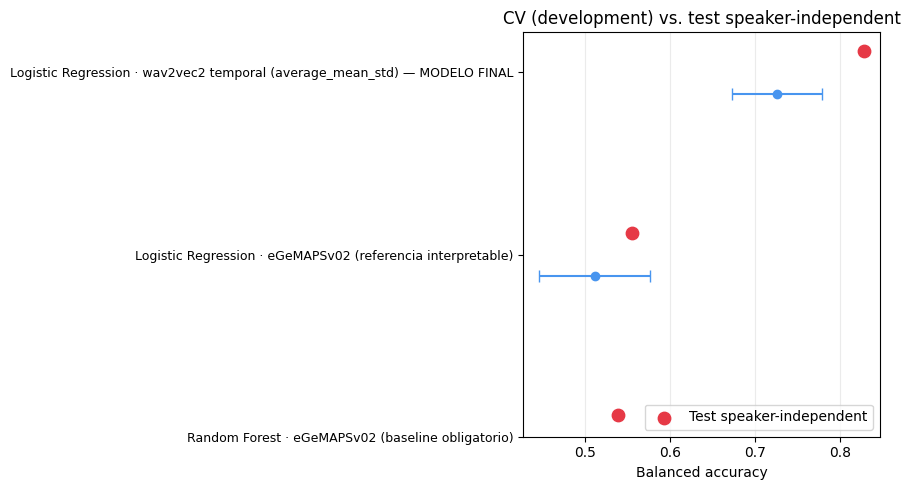

In [8]:
# Estimaciones de CV documentadas en 03c (temporal_pooling_layer_mixture.ipynb / 03_baselines_refinement.ipynb)
CV_REFERENCE = {
    "baseline_rf_egemaps": {"mean": None, "std": None},          # completar si se corrió RF sobre egemaps en 03
    "reference_lr_egemaps": {"mean": 0.511, "std": 0.065},        # balanced_accuracy, 03b
    "final_lr_wav2vec_temporal": {"mean": 0.726, "std": 0.053},   # balanced_accuracy, temporal_pooling_layer_mixture
}

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(FINAL_MODELS))
labels = []
for i, name in enumerate(FINAL_MODELS):
    ref = CV_REFERENCE.get(name, {})
    labels.append(FINAL_MODELS[name]["label"])
    if ref.get("mean") is not None:
        ax.errorbar(ref["mean"], i - 0.12, xerr=ref["std"], fmt="o", color="#4895EF",
                     capsize=4, label="CV (development)" if i == 0 else None)
    ax.scatter(test_results[name]["balanced_accuracy"], i + 0.12, color="#E63946", s=80,
                label="Test speaker-independent" if i == 0 else None, zorder=3)

ax.set_yticks(y_pos, labels, fontsize=9)
ax.set_xlabel("Balanced accuracy")
ax.set_title("CV (development) vs. test speaker-independent")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "test_vs_cv_gap.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 · Reporte por clase — modelo final

In [9]:
best_name = "final_lr_wav2vec_temporal"
best = test_results[best_name]

report = classification_report(best["y_true"], best["y_pred"], labels=LABELS, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(3)
report_df.to_csv(REPORTS_DIR / "test_classification_report_final_model.csv")
display(report_df)

,precision,recall,f1-score,support
angry,0.933,0.875,0.903,32.000
calm,0.722,0.812,0.765,32.000
disgust,0.853,0.906,0.879,32.000
fearful,0.903,0.875,0.889,32.000
happy,0.913,0.656,0.764,32.000
neutral,0.615,1.000,0.762,16.000
sad,1.000,0.500,0.667,32.000
surprised,0.727,1.000,0.842,32.000
accuracy,0.817,0.817,0.817,0.817
macro avg,0.833,0.828,0.809,240.000


### 6.3 · Matrices de confusión normalizadas (test)

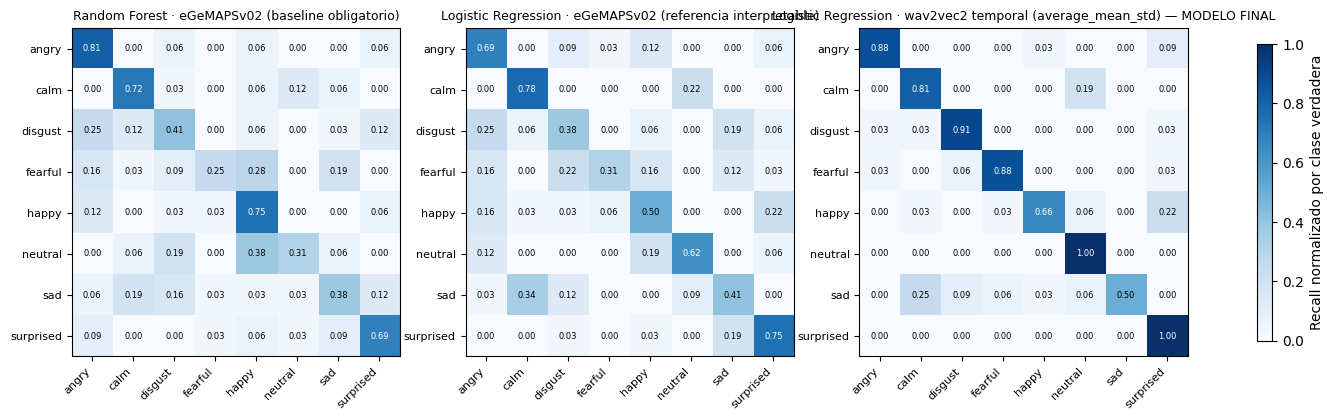

In [10]:
fig, axes = plt.subplots(1, len(FINAL_MODELS), figsize=(6 * len(FINAL_MODELS), 5.5))

for ax, (name, spec) in zip(axes, FINAL_MODELS.items()):
    r = test_results[name]
    cm = confusion_matrix(r["y_true"], r["y_pred"], labels=LABELS, normalize="true")
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(LABELS)), LABELS, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(LABELS)), LABELS, fontsize=8)
    ax.set_title(spec["label"], fontsize=9)
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                     fontsize=6, color="white" if cm[i, j] > 0.5 else "black")

fig.colorbar(im, ax=axes, shrink=0.7, label="Recall normalizado por clase verdadera")
plt.savefig(FIGURES_DIR / "test_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7 · Q3 (sad) vs. Q4 (calm/neutral) en test

Este es el cuello de botella identificado en Sprints 2–3: ambos cuadrantes comparten *low arousal* y solo difieren en *valence*. Se verifica si persiste en test, colapsando las predicciones del modelo final a cuadrantes.

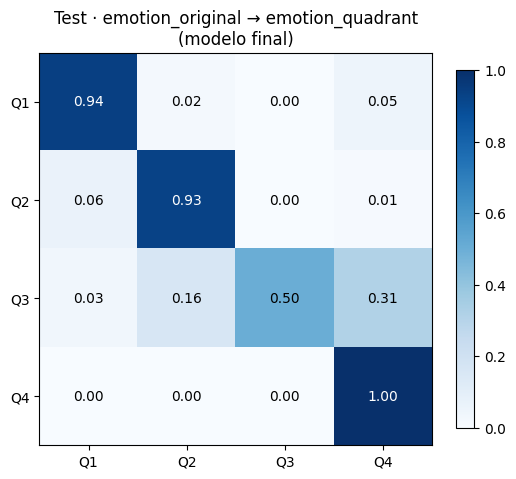

Recall Q3 (sad): 0.500
Q3 confundido como Q4: 0.312


In [11]:
y_true_q = pd.Series(best["y_true"]).map(QUADRANT_MAP).to_numpy()
y_pred_q = pd.Series(best["y_pred"]).map(QUADRANT_MAP).to_numpy()

quadrant_labels = ["Q1", "Q2", "Q3", "Q4"]
cm_q = confusion_matrix(y_true_q, y_pred_q, labels=quadrant_labels, normalize="true")

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_q, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4), quadrant_labels)
ax.set_yticks(range(4), quadrant_labels)
ax.set_title("Test · emotion_original → emotion_quadrant\n(modelo final)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm_q[i, j]:.2f}", ha="center", va="center",
                 fontsize=10, color="white" if cm_q[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "test_confusion_quadrants.png", dpi=150, bbox_inches="tight")
plt.show()

q3_recall = cm_q[quadrant_labels.index("Q3"), quadrant_labels.index("Q3")]
q3_to_q4 = cm_q[quadrant_labels.index("Q3"), quadrant_labels.index("Q4")]
print(f"Recall Q3 (sad): {q3_recall:.3f}")
print(f"Q3 confundido como Q4: {q3_to_q4:.3f}")

### 7.1 · Desempeño por actor de test

Solo 4 actores componen el test; conviene chequear si el resultado global esconde a un actor particularmente difícil (mismo diagnóstico hecho en `03b` sobre development).

C:\Users\franc\AppData\Local\Temp\ipykernel_11332\2768221549.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: balanced_accuracy_score(g["y_true"], g["y_pred"]))


,actor_id,balanced_accuracy
3,23,0.671875
2,21,0.843750
1,6,0.859375
0,2,0.937500


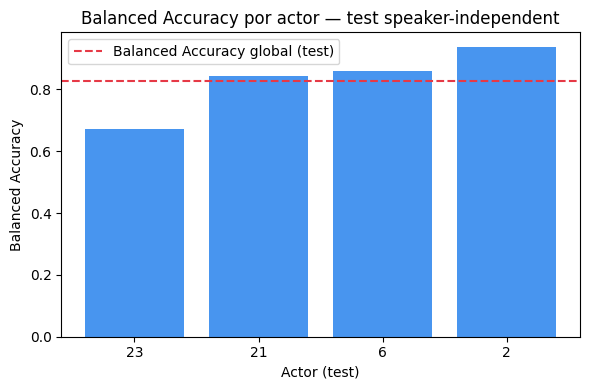

In [12]:
_, _, _, _, _, file_ids_test = datasets[best_name]
actor_lookup = full.set_index("file_id")["actor_id"]

per_file = pd.DataFrame({
    "file_id": best["file_id"],
    "y_true": best["y_true"],
    "y_pred": best["y_pred"],
})
per_file["actor_id"] = per_file["file_id"].map(actor_lookup)
per_file["correct"] = per_file["y_true"] == per_file["y_pred"]

per_actor = (
    per_file.groupby("actor_id")
    .apply(lambda g: balanced_accuracy_score(g["y_true"], g["y_pred"]))
    .rename("balanced_accuracy")
    .reset_index()
    .sort_values("balanced_accuracy")
)
display(per_actor)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(per_actor["actor_id"].astype(str), per_actor["balanced_accuracy"], color="#4895EF")
ax.axhline(best["balanced_accuracy"], color="#E63946", linestyle="--", label="Balanced Accuracy global (test)")
ax.set_xlabel("Actor (test)")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Balanced Accuracy por actor — test speaker-independent")
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Artefactos guardados

```text
reports/test_results_summary.csv
reports/test_classification_report_final_model.csv
reports/figures/test_vs_cv_gap.png
reports/figures/test_confusion_matrices.png
reports/figures/test_confusion_quadrants.png
```

Estos son los insumos directos para el póster (número principal, gap CV↔test, matriz de confusión y la lectura Q3/Q4).

---
## 9 · Conclusiones del notebook

**Resultado principal:** el modelo final — Logistic Regression sobre wav2vec2 temporal con `average_mean_std` (promedio uniforme de las 13 capas, media + desvío) — alcanza en `test_speaker_independent` los números reportados en la Sección 6, frente a una estimación de CV de balanced accuracy = 0.726 ± 0.053 (peor fold = 0.637) obtenida en `development`.

**Lectura del gap CV↔test:** si el punto de test cae dentro de la banda ±1 desvío de la estimación de CV, el pipeline generaliza de forma consistente con lo esperado por el protocolo speaker-independent; si cae por fuera, el desvío entre folds documentado en Sprint 3c ya anticipaba esa variabilidad y **no** amerita volver a tocar el test.

**Q3 vs Q4:** la confusión sad↔calm/neutral (comparten low arousal, difieren en valence) es la referencia central para el póster — Sección 7 confirma si el patrón observado en `development` (03b) persiste en test.

**Pendiente explícito:** si las variantes Gaussian/bimodal de `03c` (`GaussianLayerPooling`, `BimodalLayerPooling`) se cierran con una mejora de CV antes de la entrega, el modelo final de este notebook debería reemplazarse antes de fijar el número del póster — hoy `average_mean_std` es la referencia más sólida y validada.